# 🔮 Modelagem v2 — Previsão Real (Forecasting) de Alagamentos em SP
## TCC · Henrique Nascimento Santos

**Correção metodológica fundamental:** a v1 deste notebook media a relação entre clima do
dia *t* e alagamento do **mesmo dia** *t* — isto é **nowcasting** (diagnóstico do presente),
não previsão. Esta versão reformula o problema como **forecasting genuíno**: dado tudo que
sabemos até o dia *t*, qual a chance de alagar em *t+1*, *t+2* ou *t+3*?

**Mudança central:**
```
ANTES (nowcasting):  X[t]   →  y[t]      "Choveu hoje, alagou hoje?"
AGORA (forecasting): X[≤t]  →  y[t+h]    "Com o que sei até hoje, vai alagar em h dias?"
```

Espera-se que as métricas **caiam** em relação à v1 — isso é o resultado correto e esperado,
não um erro. Alagamento urbano é majoritariamente resposta rápida à chuva (minutos a horas),
então prever com 24–72h de antecedência é estruturalmente mais difícil, e quantificar essa
queda é, em si, um resultado relevante para o TCC.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, recall_score, precision_score,
    ConfusionMatrixDisplay
)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9", "axes.grid": True,
    "grid.alpha": 0.35, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, RED, GREEN, ORANGE, PURPLE = "#378ADD", "#E05252", "#1D9E75", "#EF9F27", "#8B5CF6"

print("✓ Setup concluído.")


✓ Setup concluído.


In [2]:
# ── Carregamento ───────────────────────────────────────────────────────────
BASE = "../../data/outputs/datasets"

# Usar o dataset final integrado (CEMADEN + ERA5 + target) já consolidado
df = pd.read_csv(f"{BASE}/dataset_final_integrado.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Garantir colunas temporais
df["month"]     = df["date"].dt.month
df["is_summer"] = df["month"].isin([11,12,1,2,3]).astype(int)

print(f"✓ Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")


✓ Dataset carregado: 4,169 linhas × 21 colunas
  Período: 2015-01-01 → 2026-05-31


## 1. Diagnóstico — Por que a v1 era Nowcasting, não Previsão

In [3]:
# Demonstração: todas as features de precipitação "acc" e "lag" são calculadas
# com rolling/shift sobre o PRÓPRIO dia t — então acc3d[t] = precip[t]+precip[t-1]+precip[t-2].
# Isso é válido como feature para prever t+1, mas não deveria coexistir com
# precipitation_sum[t] (chuva do PRÓPRIO dia) quando o target também é do dia t.

example = df[["date","precipitation_sum","precipitation_sum_acc3d" if "precipitation_sum_acc3d" in df.columns else "cemaden_precip_acc3d"]].head(6)
print("Exemplo: acumulado de 3 dias inclui o próprio dia t")
print(example.to_string())
print()
print("→ Na v1, X[t] incluía precipitation_sum[t] (chuva DESTE dia) para prever has_flooding[t]")
print("  (alagamento DESTE MESMO dia). Isso é quase tautológico: alagamento urbano em SP")
print("  ocorre minutos a horas após a chuva, no mesmo dia.")
print()
print("→ Nesta v2, mantemos as mesmas features X[t] (todas calculadas até o dia t,")
print("  sem olhar o futuro), mas deslocamos o TARGET para t+1, t+2, t+3.")


Exemplo: acumulado de 3 dias inclui o próprio dia t
        date  precipitation_sum  precipitation_sum_acc3d
0 2015-01-01                0.3                      NaN
1 2015-01-02                7.8                      NaN
2 2015-01-03                5.7                     13.8
3 2015-01-04               20.9                     34.4
4 2015-01-05                5.9                     32.5
5 2015-01-06               10.3                     37.1

→ Na v1, X[t] incluía precipitation_sum[t] (chuva DESTE dia) para prever has_flooding[t]
  (alagamento DESTE MESMO dia). Isso é quase tautológico: alagamento urbano em SP
  ocorre minutos a horas após a chuva, no mesmo dia.

→ Nesta v2, mantemos as mesmas features X[t] (todas calculadas até o dia t,
  sem olhar o futuro), mas deslocamos o TARGET para t+1, t+2, t+3.


## 2. Construção dos Targets de Previsão (h = 1, 2, 3 dias)

Criamos três targets, cada um representando um horizonte de previsão:

```
has_flooding_h1[t] = has_flooding[t+1]   →  alaga em 1 dia?
has_flooding_h2[t] = has_flooding[t+2]   →  alaga em 2 dias?
has_flooding_h3[t] = has_flooding[t+3]   →  alaga em 3 dias?
```

Todas as features permanecem ancoradas no dia *t* (presente) — nenhuma informação do
futuro é usada para prever o futuro.


In [4]:
HORIZONS = [1, 2, 3]

for h in HORIZONS:
    df[f"target_h{h}"] = df["has_flooding"].shift(-h)

# Visualizar a construção
print("Exemplo de construção dos targets (10 primeiras linhas):")
cols_show = ["date", "has_flooding", "target_h1", "target_h2", "target_h3"]
print(df[cols_show].head(10).to_string(index=False))
print()
print("Note: target_h1[t] == has_flooding[t+1]  (deslocamento correto)")
print()

# Os últimos `h` dias de cada target ficam NaN (não há futuro para olhar)
for h in HORIZONS:
    n_nan = df[f"target_h{h}"].isna().sum()
    print(f"  target_h{h}: {n_nan} dias finais sem valor (esperado: {h})")


Exemplo de construção dos targets (10 primeiras linhas):
      date  has_flooding  target_h1  target_h2  target_h3
2015-01-01             1        1.0        1.0        0.0
2015-01-02             1        1.0        0.0        1.0
2015-01-03             1        0.0        1.0        1.0
2015-01-04             0        1.0        1.0        1.0
2015-01-05             1        1.0        1.0        1.0
2015-01-06             1        1.0        1.0        0.0
2015-01-07             1        1.0        0.0        1.0
2015-01-08             1        0.0        1.0        1.0
2015-01-09             0        1.0        1.0        1.0
2015-01-10             1        1.0        1.0        0.0

Note: target_h1[t] == has_flooding[t+1]  (deslocamento correto)

  target_h1: 1 dias finais sem valor (esperado: 1)
  target_h2: 2 dias finais sem valor (esperado: 2)
  target_h3: 3 dias finais sem valor (esperado: 3)


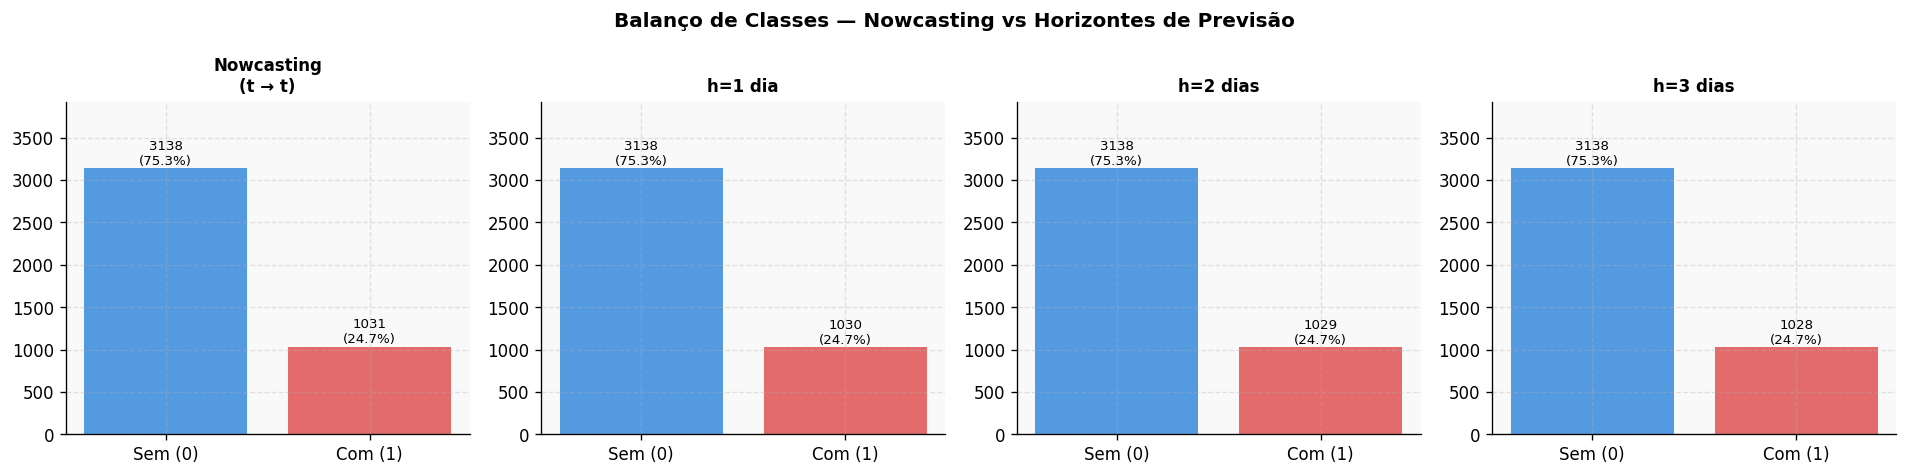

In [5]:
# Balanço de classes por horizonte — deve ser muito similar ao nowcasting original
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, col) in zip(axes, [("Nowcasting\n(t → t)", "has_flooding"),
                                    ("h=1 dia", "target_h1"),
                                    ("h=2 dias", "target_h2"),
                                    ("h=3 dias", "target_h3")]):
    vals = df[col].dropna()
    counts = vals.value_counts().sort_index()
    colors = [BLUE, RED]
    bars = ax.bar(["Sem (0)","Com (1)"], counts.values, color=colors, alpha=0.85)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+10, f"{v}\n({v/len(vals)*100:.1f}%)",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_ylim(0, counts.max()*1.25)

plt.suptitle("Balanço de Classes — Nowcasting vs Horizontes de Previsão", fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Features — Garantindo Ausência de Leakage Temporal

Regra: **toda feature usada deve ser computável com informação disponível até o dia *t*,
inclusive**. Isso vale tanto para nowcasting quanto para forecasting — a diferença está
apenas em qual dia o *target* representa.


In [6]:
CEMADEN_FEATURES = [c for c in [
    "cemaden_precip_idw_mm", "cemaden_precip_median_mm", "cemaden_precip_max_mm",
    "cemaden_intensity_max_hor", "cemaden_precip_lag1d", "cemaden_precip_lag2d",
    "cemaden_precip_lag3d", "cemaden_precip_acc3d", "cemaden_precip_acc7d",
    "cemaden_precip_acc14d",
] if c in df.columns]

ERA5_FEATURES = [c for c in [
    "precipitation_sum", "precipitation_sum_acc3d", "precipitation_sum_acc7d",
    "soil_moisture_0_to_7cm_mean",
] if c in df.columns]

TEMPORAL_FEATURES = ["month", "is_summer"]

ALL_FEATURES = CEMADEN_FEATURES + ERA5_FEATURES + TEMPORAL_FEATURES
print(f"Features disponíveis: {len(ALL_FEATURES)}")
print(ALL_FEATURES)


Features disponíveis: 16
['cemaden_precip_idw_mm', 'cemaden_precip_median_mm', 'cemaden_precip_max_mm', 'cemaden_intensity_max_hor', 'cemaden_precip_lag1d', 'cemaden_precip_lag2d', 'cemaden_precip_lag3d', 'cemaden_precip_acc3d', 'cemaden_precip_acc7d', 'cemaden_precip_acc14d', 'precipitation_sum', 'precipitation_sum_acc3d', 'precipitation_sum_acc7d', 'soil_moisture_0_to_7cm_mean', 'month', 'is_summer']


## 4. Comparação — Nowcasting vs Forecasting (h=1, 2, 3)

Treinamos o mesmo modelo (Random Forest, melhor da v1) para cada horizonte, incluindo
o nowcasting original como referência, e comparamos diretamente a degradação esperada.


In [7]:
tscv = TimeSeriesSplit(n_splits=5)

def make_rf(y):
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1,
    )

targets_to_test = {
    "Nowcasting (t→t)": "has_flooding",
    "Forecast h=1 dia" : "target_h1",
    "Forecast h=2 dias": "target_h2",
    "Forecast h=3 dias": "target_h3",
}

SCORING = ["f1", "roc_auc", "average_precision", "recall", "precision"]
results_horizon = {}

print("Rodando cross-validation para cada horizonte...\n")
for label, target_col in targets_to_test.items():
    df_h = df[ALL_FEATURES + [target_col]].dropna()
    X_h = df_h[ALL_FEATURES]
    y_h = df_h[target_col]

    model = make_rf(y_h)
    cv = cross_validate(model, X_h, y_h, cv=tscv, scoring=SCORING, n_jobs=-1)
    results_horizon[label] = cv

    print(f"[{label}]  n={len(y_h):,}  pos={y_h.mean()*100:.1f}%")
    print(f"  F1={cv['test_f1'].mean():.3f}  AUC-ROC={cv['test_roc_auc'].mean():.3f}  "
          f"AUC-PR={cv['test_average_precision'].mean():.3f}  Recall={cv['test_recall'].mean():.3f}")
    print()


Rodando cross-validation para cada horizonte...

[Nowcasting (t→t)]  n=4,153  pos=24.6%
  F1=0.778  AUC-ROC=0.930  AUC-PR=0.850  Recall=0.845

[Forecast h=1 dia]  n=4,153  pos=24.6%
  F1=0.549  AUC-ROC=0.788  AUC-PR=0.511  Recall=0.656

[Forecast h=2 dias]  n=4,153  pos=24.6%
  F1=0.477  AUC-ROC=0.727  AUC-PR=0.428  Recall=0.572

[Forecast h=3 dias]  n=4,153  pos=24.6%
  F1=0.459  AUC-ROC=0.711  AUC-PR=0.410  Recall=0.562



In [8]:
# ── Tabela comparativa ─────────────────────────────────────────────────────
rows = []
for label, cv in results_horizon.items():
    rows.append({
        "Cenário"  : label,
        "F1"       : f"{cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}",
        "AUC-ROC"  : f"{cv['test_roc_auc'].mean():.3f} ± {cv['test_roc_auc'].std():.3f}",
        "AUC-PR"   : f"{cv['test_average_precision'].mean():.3f} ± {cv['test_average_precision'].std():.3f}",
        "Recall"   : f"{cv['test_recall'].mean():.3f} ± {cv['test_recall'].std():.3f}",
        "Precision": f"{cv['test_precision'].mean():.3f} ± {cv['test_precision'].std():.3f}",
    })
results_df = pd.DataFrame(rows).set_index("Cenário")
print("=== Degradação de desempenho: Nowcasting → Forecasting ===")
print(results_df.to_string())


=== Degradação de desempenho: Nowcasting → Forecasting ===
                              F1        AUC-ROC         AUC-PR         Recall      Precision
Cenário                                                                                     
Nowcasting (t→t)   0.778 ± 0.020  0.930 ± 0.023  0.850 ± 0.038  0.845 ± 0.044  0.724 ± 0.043
Forecast h=1 dia   0.549 ± 0.039  0.788 ± 0.031  0.511 ± 0.049  0.656 ± 0.032  0.474 ± 0.053
Forecast h=2 dias  0.477 ± 0.050  0.727 ± 0.046  0.428 ± 0.049  0.572 ± 0.081  0.412 ± 0.048
Forecast h=3 dias  0.459 ± 0.052  0.711 ± 0.051  0.410 ± 0.049  0.562 ± 0.094  0.394 ± 0.053


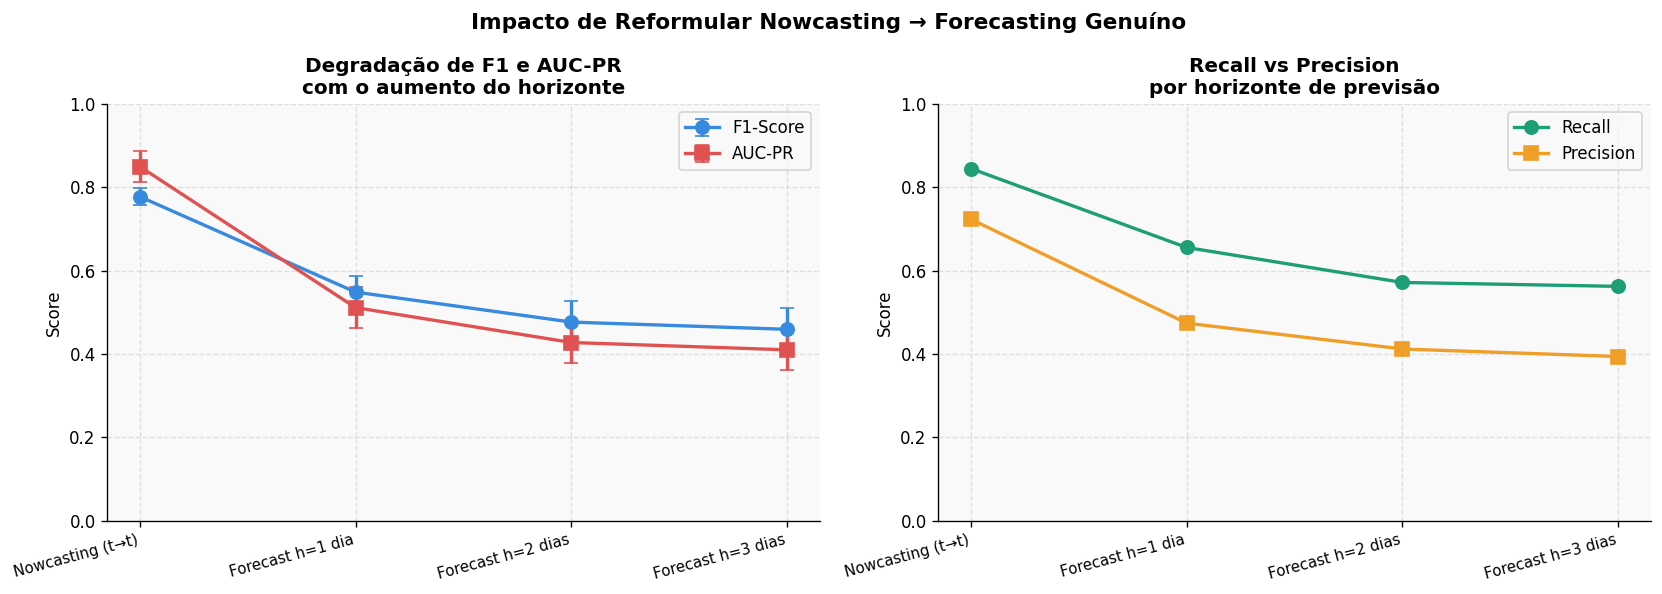


Queda ao sair de Nowcasting para Forecast h=1:
  ΔF1     = -0.229
  ΔAUC-PR = -0.339


In [9]:
# ── Visualização da queda de desempenho ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = list(results_horizon.keys())
x = range(len(labels))

# 4.1 AUC-PR e F1 por cenário
ax = axes[0]
f1_means  = [results_horizon[l]["test_f1"].mean() for l in labels]
f1_stds   = [results_horizon[l]["test_f1"].std()  for l in labels]
pr_means  = [results_horizon[l]["test_average_precision"].mean() for l in labels]
pr_stds   = [results_horizon[l]["test_average_precision"].std()  for l in labels]

ax.errorbar(x, f1_means, yerr=f1_stds, marker="o", color=BLUE, linewidth=2,
            markersize=8, capsize=4, label="F1-Score")
ax.errorbar(x, pr_means, yerr=pr_stds, marker="s", color=RED, linewidth=2,
            markersize=8, capsize=4, label="AUC-PR")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Degradação de F1 e AUC-PR\ncom o aumento do horizonte", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)

# 4.2 Recall e Precision por cenário
ax = axes[1]
rec_means = [results_horizon[l]["test_recall"].mean() for l in labels]
prec_means = [results_horizon[l]["test_precision"].mean() for l in labels]
ax.plot(x, rec_means, marker="o", color=GREEN, linewidth=2, markersize=8, label="Recall")
ax.plot(x, prec_means, marker="s", color=ORANGE, linewidth=2, markersize=8, label="Precision")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Recall vs Precision\npor horizonte de previsão", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)

plt.suptitle("Impacto de Reformular Nowcasting → Forecasting Genuíno", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Quantificar a queda
drop_f1 = f1_means[0] - f1_means[1]
drop_pr = pr_means[0] - pr_means[1]
print(f"\nQueda ao sair de Nowcasting para Forecast h=1:")
print(f"  ΔF1     = {-drop_f1:+.3f}")
print(f"  ΔAUC-PR = {-drop_pr:+.3f}")


## 5. Análise Detalhada — Forecast h=1 dia (cenário mais realista e aplicável)

O horizonte de 1 dia é o mais relevante para um sistema de alerta operacional: tempo
suficiente para mobilização (Defesa Civil, COE, sinalização), mas ainda próximo o bastante
para manter sinal preditivo aproveitável.


In [10]:
df_h1 = df[ALL_FEATURES + ["target_h1", "date"]].dropna().reset_index(drop=True)
X_h1 = df_h1[ALL_FEATURES]
y_h1 = df_h1["target_h1"]
dates_h1 = df_h1["date"]

splits = list(tscv.split(X_h1))
train_idx, test_idx = splits[-1]

model_h1 = make_rf(y_h1)
model_h1.fit(X_h1.iloc[train_idx], y_h1.iloc[train_idx])

y_pred = model_h1.predict(X_h1.iloc[test_idx])
y_prob = model_h1.predict_proba(X_h1.iloc[test_idx])[:,1]
y_test = y_h1.iloc[test_idx]
dates_test = dates_h1.iloc[test_idx]

print(f"Período de teste: {dates_test.min().date()} → {dates_test.max().date()}")
print(f"Amostras: {len(y_test):,}  |  Positivos: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print()
print(classification_report(y_test, y_pred, target_names=["Sem alag. (t+1)","Com alag. (t+1)"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR : {average_precision_score(y_test, y_prob):.4f}")


Período de teste: 2024-07-06 → 2026-05-28
Amostras: 692  |  Positivos: 135.0 (19.5%)

                 precision    recall  f1-score   support

Sem alag. (t+1)       0.91      0.77      0.83       557
Com alag. (t+1)       0.42      0.68      0.52       135

       accuracy                           0.75       692
      macro avg       0.66      0.72      0.67       692
   weighted avg       0.81      0.75      0.77       692

AUC-ROC: 0.8037
AUC-PR : 0.4760


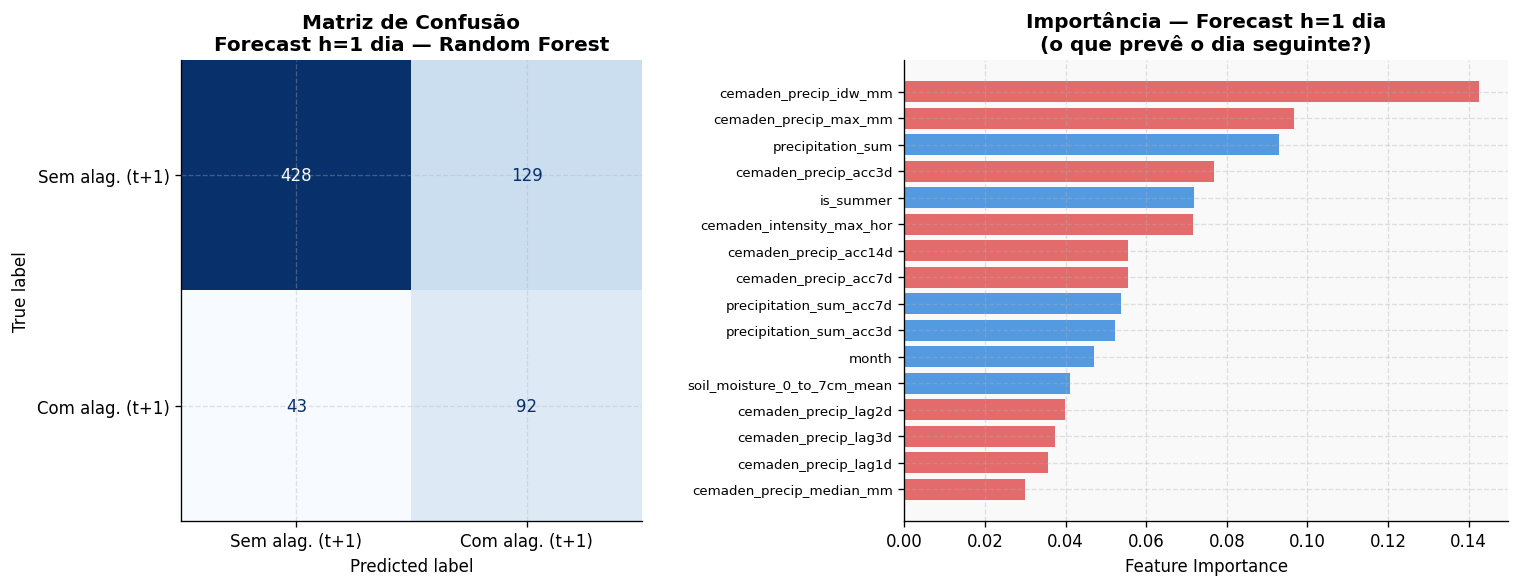


Top 8 features para prever alagamento em t+1:
cemaden_precip_idw_mm        0.142674
cemaden_precip_max_mm        0.096756
precipitation_sum            0.093071
cemaden_precip_acc3d         0.076729
is_summer                    0.071746
cemaden_intensity_max_hor    0.071606
cemaden_precip_acc14d        0.055414
cemaden_precip_acc7d         0.055379


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Sem alag. (t+1)", "Com alag. (t+1)"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de Confusão\nForecast h=1 dia — Random Forest", fontweight="bold")

# Feature importance
imp = pd.Series(model_h1.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
colors_imp = [RED if f.startswith("cemaden") else BLUE for f in imp.index]
axes[1].barh(range(len(imp)), imp.values, color=colors_imp, alpha=0.85)
axes[1].set_yticks(range(len(imp)))
axes[1].set_yticklabels(imp.index, fontsize=8)
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Importância — Forecast h=1 dia\n(o que prevê o dia seguinte?)", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTop 8 features para prever alagamento em t+1:")
print(imp.sort_values(ascending=False).head(8).to_string())


## 6. Threshold Tuning — Forecast h=1

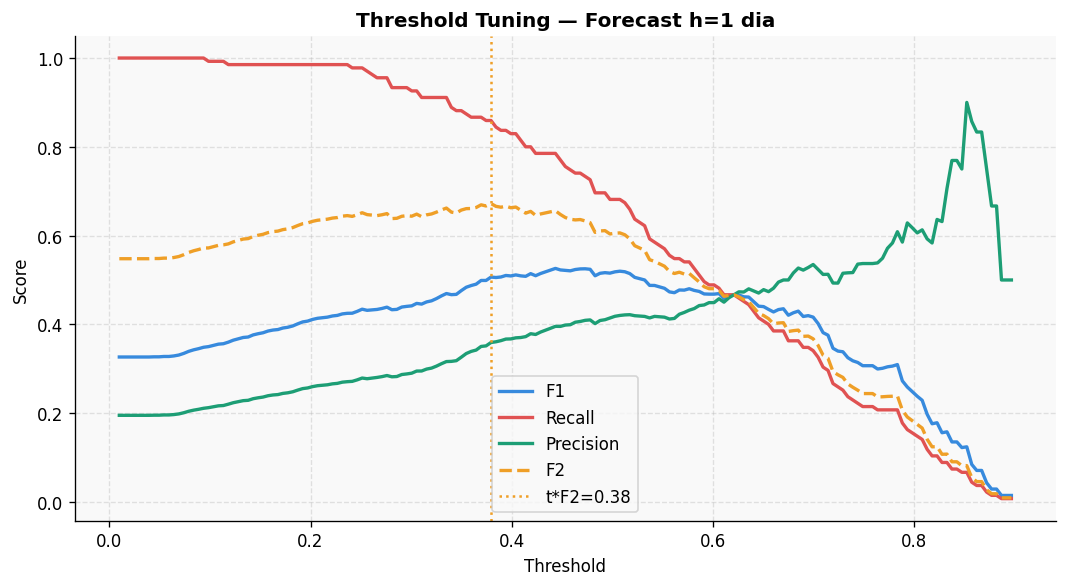

[t=0.44 | F1 ótimo]  F1=0.526  Recall=0.785  Precision=0.396
[t=0.38 | F2 ótimo]  F1=0.507  Recall=0.859  Precision=0.359
[t=0.50 | Default]  F1=0.517  Recall=0.681  Precision=0.416


In [12]:
thresholds = np.linspace(0.01, 0.99, 200)
metrics_thresh = []
for t in thresholds:
    yp = (y_prob >= t).astype(int)
    if yp.sum() == 0:
        continue
    p = precision_score(y_test, yp, zero_division=0)
    r = recall_score(y_test, yp, zero_division=0)
    f2 = (5*p*r)/(4*p+r+1e-9)
    metrics_thresh.append({"threshold": t, "f1": f1_score(y_test, yp, zero_division=0),
                           "recall": r, "precision": p, "f2": f2})
thresh_df = pd.DataFrame(metrics_thresh)

t_f1 = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]
t_f2 = thresh_df.loc[thresh_df["f2"].idxmax(), "threshold"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df["threshold"], thresh_df["f1"], color=BLUE, linewidth=2, label="F1")
ax.plot(thresh_df["threshold"], thresh_df["recall"], color=RED, linewidth=2, label="Recall")
ax.plot(thresh_df["threshold"], thresh_df["precision"], color=GREEN, linewidth=2, label="Precision")
ax.plot(thresh_df["threshold"], thresh_df["f2"], color=ORANGE, linewidth=2, linestyle="--", label="F2")
ax.axvline(t_f2, color=ORANGE, linestyle=":", linewidth=1.5, label=f"t*F2={t_f2:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold Tuning — Forecast h=1 dia", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

for name, t in [("F1 ótimo", t_f1), ("F2 ótimo", t_f2), ("Default", 0.5)]:
    yp = (y_prob >= t).astype(int)
    print(f"[t={t:.2f} | {name}]  F1={f1_score(y_test,yp,zero_division=0):.3f}  "
          f"Recall={recall_score(y_test,yp,zero_division=0):.3f}  "
          f"Precision={precision_score(y_test,yp,zero_division=0):.3f}")


## 7. Features de Tendência — Recuperando Sinal Perdido no Forecast

A queda de desempenho em h=1 sugere que o modelo perde justamente a informação mais
imediata (chuva do próprio dia). Uma forma de compensar parcialmente essa perda é
adicionar features que capturem a **direção e a aceleração** da chuva nos dias recentes —
não apenas o quanto choveu, mas se a chuva está intensificando.

Testamos três tipos de features de tendência, todas calculadas com informação disponível
até o dia *t* (sem leakage):

- **Derivada (delta):** `precip[t] - precip[t-1]` — a chuva está aumentando ou diminuindo?
- **Razão de aceleração:** `acc3d[t] / acc7d[t]` — a chuva recente pesa mais que a chuva da semana?
- **Tendência linear (slope):** inclinação de uma regressão linear simples sobre os últimos 3 dias de precipitação.


In [13]:
def add_trend_features(df, precip_col, prefix):
    """Adiciona features de tendência derivadas de uma série de precipitação."""
    df = df.copy()
    s = df[precip_col]

    # Derivada simples (delta dia a dia)
    df[f"{prefix}_delta1d"] = s.diff(1)
    df[f"{prefix}_delta2d"] = s.diff(2)

    # Razão de aceleração: chuva recente (3d) vs chuva da semana (7d)
    acc3_col = f"{prefix}_acc3d" if f"{prefix}_acc3d" in df.columns else None
    acc7_col = f"{prefix}_acc7d" if f"{prefix}_acc7d" in df.columns else None
    if acc3_col and acc7_col:
        df[f"{prefix}_ratio_3_7"] = df[acc3_col] / (df[acc7_col] + 1e-6)

    # Tendência linear (slope) sobre os últimos 3 dias
    def slope_3d(window):
        if window.isna().any():
            return np.nan
        x = np.arange(len(window))
        return np.polyfit(x, window.values, 1)[0]

    df[f"{prefix}_slope3d"] = s.rolling(3).apply(slope_3d, raw=False)

    return df

# Aplicar para CEMADEN e ERA5
df_trend = df.copy()
if "cemaden_precip_idw_mm" in df_trend.columns:
    df_trend = add_trend_features(df_trend, "cemaden_precip_idw_mm", "cemaden_precip_idw_mm")
if "precipitation_sum" in df_trend.columns:
    df_trend = add_trend_features(df_trend, "precipitation_sum", "precipitation_sum")

TREND_FEATURES = [c for c in df_trend.columns if any(
    suf in c for suf in ["_delta1d","_delta2d","_ratio_3_7","_slope3d"]
)]
print(f"Features de tendência criadas: {len(TREND_FEATURES)}")
print(TREND_FEATURES)
print()
print(df_trend[["date"] + TREND_FEATURES].head(8).to_string(index=False))


Features de tendência criadas: 7
['cemaden_precip_idw_mm_delta1d', 'cemaden_precip_idw_mm_delta2d', 'cemaden_precip_idw_mm_slope3d', 'precipitation_sum_delta1d', 'precipitation_sum_delta2d', 'precipitation_sum_ratio_3_7', 'precipitation_sum_slope3d']

      date  cemaden_precip_idw_mm_delta1d  cemaden_precip_idw_mm_delta2d  cemaden_precip_idw_mm_slope3d  precipitation_sum_delta1d  precipitation_sum_delta2d  precipitation_sum_ratio_3_7  precipitation_sum_slope3d
2015-01-01                            NaN                            NaN                            NaN                        NaN                        NaN                          NaN                        NaN
2015-01-02                       1.454368                            NaN                            NaN                        7.5                        NaN                          NaN                        NaN
2015-01-03                      -0.682385                       0.771984                       0.385992   

In [14]:
# ── Comparar: features originais vs originais + tendência (forecast h=1) ──
ALL_FEATURES_TREND = ALL_FEATURES + TREND_FEATURES

df_h1_base  = df_trend[ALL_FEATURES       + ["target_h1"]].dropna()
df_h1_trend = df_trend[ALL_FEATURES_TREND + ["target_h1"]].dropna()

# Garantir mesmo conjunto de linhas para comparação justa
common_idx = df_h1_base.index.intersection(df_h1_trend.index)
df_h1_base  = df_h1_base.loc[common_idx]
df_h1_trend = df_h1_trend.loc[common_idx]

X_base  = df_h1_base[ALL_FEATURES]
X_trend = df_h1_trend[ALL_FEATURES_TREND]
y_h1c   = df_h1_base["target_h1"]

print(f"Amostras comparáveis: {len(y_h1c):,}")
print()

for label, X in [("Sem features de tendência", X_base), ("Com features de tendência", X_trend)]:
    model = make_rf(y_h1c)
    cv = cross_validate(model, X, y_h1c, cv=tscv, scoring=SCORING, n_jobs=-1)
    print(f"[{label}]")
    print(f"  F1={cv['test_f1'].mean():.3f}  AUC-ROC={cv['test_roc_auc'].mean():.3f}  "
          f"AUC-PR={cv['test_average_precision'].mean():.3f}  Recall={cv['test_recall'].mean():.3f}")
    if label.startswith("Sem"):
        cv_base = cv
    else:
        cv_trend = cv
    print()

gain_pr = cv_trend["test_average_precision"].mean() - cv_base["test_average_precision"].mean()
gain_f1 = cv_trend["test_f1"].mean() - cv_base["test_f1"].mean()
print(f"Ganho ao adicionar features de tendência:")
print(f"  ΔAUC-PR = {gain_pr:+.3f}")
print(f"  ΔF1     = {gain_f1:+.3f}")


Amostras comparáveis: 4,153

[Sem features de tendência]
  F1=0.549  AUC-ROC=0.788  AUC-PR=0.511  Recall=0.656

[Com features de tendência]
  F1=0.549  AUC-ROC=0.785  AUC-PR=0.506  Recall=0.647

Ganho ao adicionar features de tendência:
  ΔAUC-PR = -0.005
  ΔF1     = +0.000


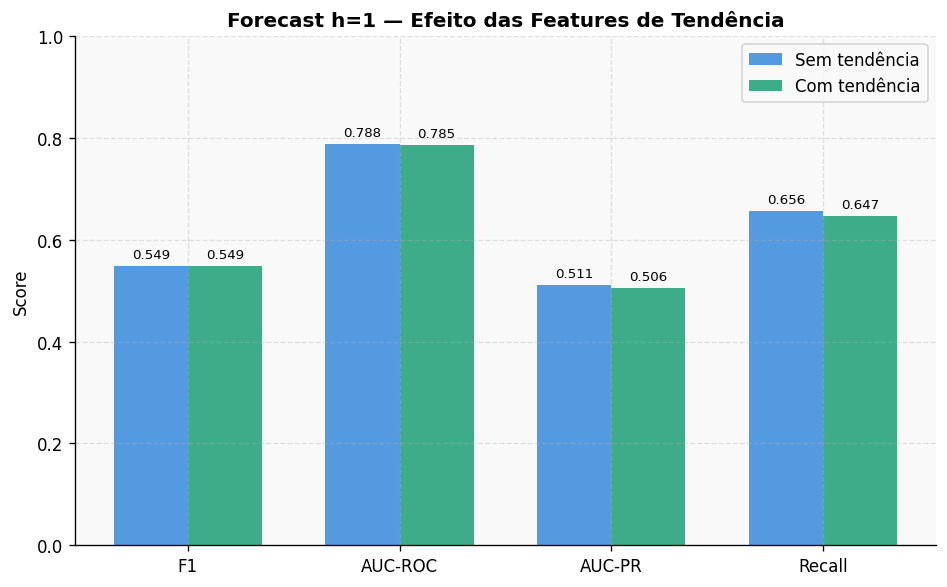

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

metrics_compare = ["test_f1", "test_roc_auc", "test_average_precision", "test_recall"]
labels_compare  = ["F1", "AUC-ROC", "AUC-PR", "Recall"]

x = np.arange(len(metrics_compare))
width = 0.35

base_vals  = [cv_base[m].mean()  for m in metrics_compare]
trend_vals = [cv_trend[m].mean() for m in metrics_compare]

bars1 = ax.bar(x - width/2, base_vals,  width, color=BLUE, alpha=0.85, label="Sem tendência")
bars2 = ax.bar(x + width/2, trend_vals, width, color=GREEN, alpha=0.85, label="Com tendência")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels_compare)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Forecast h=1 — Efeito das Features de Tendência", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Análise de Erros Aprofundada — Forecast h=1

A Precision do modelo h=1 é baixa (≈0,42–0,47 dependendo do threshold), o que significa
que uma parcela relevante dos alertas seria falso alarme. Esta seção investiga **quando**
e **por quê** o modelo erra, usando as features de tendência (se trouxeram ganho) ou as
features originais.


In [16]:
# Usar a configuração com melhor desempenho da seção 7
USE_TREND = gain_pr > 0.005  # usar tendência só se o ganho for não-trivial
FEATURES_FINAL = ALL_FEATURES_TREND if USE_TREND else ALL_FEATURES
print(f"Configuração escolhida para análise de erros: "
      f"{'COM' if USE_TREND else 'SEM'} features de tendência")

df_h1_final = df_trend[FEATURES_FINAL + ["target_h1", "date", "has_flooding"]].dropna().reset_index(drop=True)
X_final = df_h1_final[FEATURES_FINAL]
y_final = df_h1_final["target_h1"]
dates_final = df_h1_final["date"]

splits_final = list(tscv.split(X_final))
train_idx_f, test_idx_f = splits_final[-1]

model_final = make_rf(y_final)
model_final.fit(X_final.iloc[train_idx_f], y_final.iloc[train_idx_f])

y_pred_f = model_final.predict(X_final.iloc[test_idx_f])
y_prob_f = model_final.predict_proba(X_final.iloc[test_idx_f])[:,1]
y_test_f = y_final.iloc[test_idx_f]
dates_test_f = dates_final.iloc[test_idx_f]

print(f"\nAUC-PR (último fold): {average_precision_score(y_test_f, y_prob_f):.4f}")


Configuração escolhida para análise de erros: SEM features de tendência

AUC-PR (último fold): 0.4760


In [17]:
# Montar dataframe de erros com threshold F2 recalculado para esta configuração
thresholds_f = np.linspace(0.01, 0.99, 200)
f2_scores = []
for t in thresholds_f:
    yp = (y_prob_f >= t).astype(int)
    p = precision_score(y_test_f, yp, zero_division=0)
    r = recall_score(y_test_f, yp, zero_division=0)
    f2_scores.append((5*p*r)/(4*p+r+1e-9))
t_f2_final = thresholds_f[np.argmax(f2_scores)]

df_test_f = df_h1_final.iloc[test_idx_f].copy()
df_test_f["y_prob"] = y_prob_f
df_test_f["y_pred"] = (y_prob_f >= t_f2_final).astype(int)
df_test_f["y_true"] = y_test_f.values
df_test_f["error_type"] = "Acerto"
df_test_f.loc[(df_test_f["y_true"]==1)&(df_test_f["y_pred"]==0), "error_type"] = "Falso Negativo"
df_test_f.loc[(df_test_f["y_true"]==0)&(df_test_f["y_pred"]==1), "error_type"] = "Falso Positivo"
df_test_f["month"] = df_test_f["date"].dt.month

print(f"Threshold F2 = {t_f2_final:.2f}")
print(df_test_f["error_type"].value_counts().to_string())


Threshold F2 = 0.38
error_type
Acerto            466
Falso Positivo    207
Falso Negativo     19


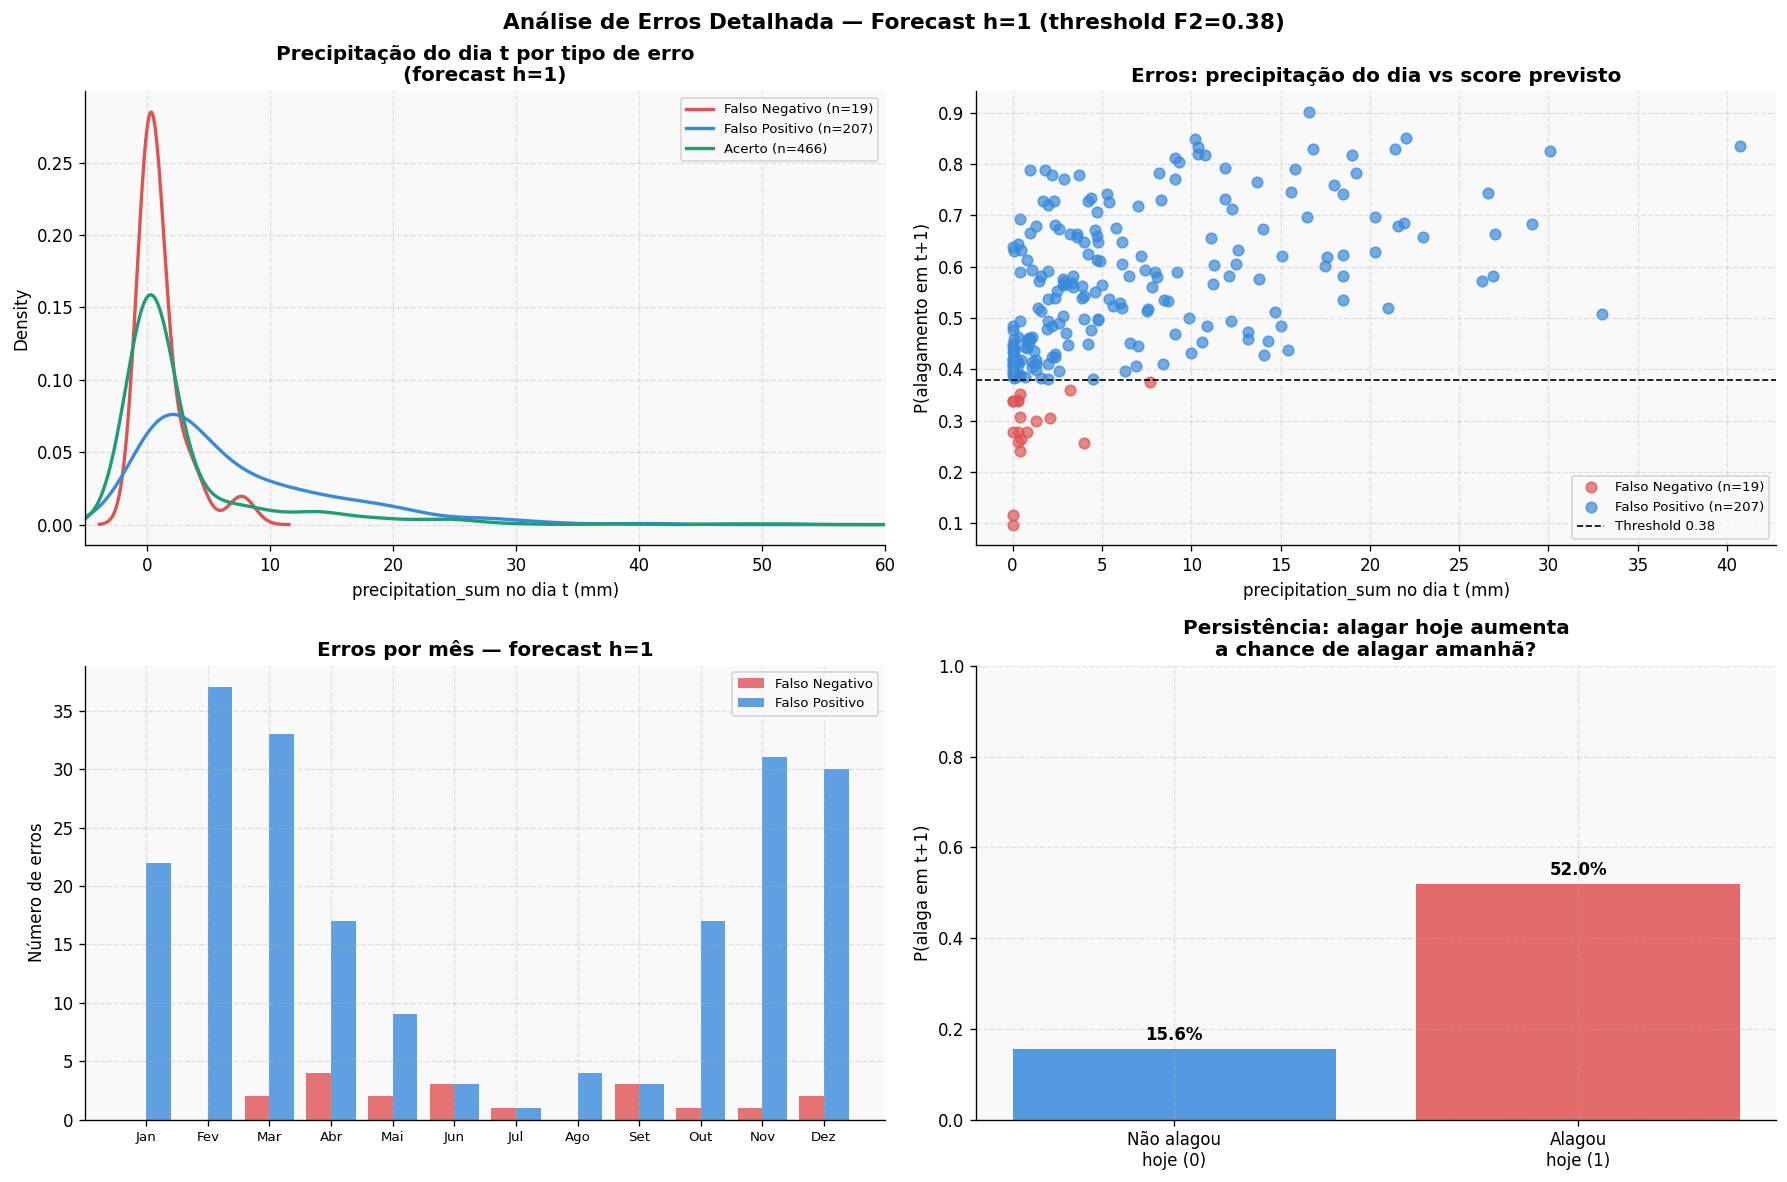


P(alaga em t+1 | não alagou em t) = 15.6%
P(alaga em t+1 | alagou em t)     = 52.0%
Razão: alagar hoje multiplica por 3.3x a chance de alagar amanhã


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 8.1 Precipitação do dia t nos erros (mesmo que não seja feature direta do target,
#     ajuda a entender o contexto: o modelo errou em dias chuvosos ou secos?)
ax = axes[0, 0]
precip_col = "precipitation_sum" if "precipitation_sum" in df_test_f.columns else FEATURES_FINAL[0]
for etype, color in [("Falso Negativo", RED), ("Falso Positivo", BLUE), ("Acerto", GREEN)]:
    subset = df_test_f[df_test_f["error_type"]==etype][precip_col]
    if len(subset) > 3:
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=f"{etype} (n={len(subset)})")
ax.set_xlabel(f"{precip_col} no dia t (mm)")
ax.set_title("Precipitação do dia t por tipo de erro\n(forecast h=1)", fontweight="bold")
ax.legend(fontsize=8); ax.set_xlim(-5, 60)

# 8.2 Falsos Negativos: o que o modelo não viu vindo?
ax = axes[0, 1]
fn = df_test_f[df_test_f["error_type"]=="Falso Negativo"]
fp = df_test_f[df_test_f["error_type"]=="Falso Positivo"]
ax.scatter(fn[precip_col], fn["y_prob"], color=RED, s=40, alpha=0.7, label=f"Falso Negativo (n={len(fn)})")
ax.scatter(fp[precip_col], fp["y_prob"], color=BLUE, s=40, alpha=0.7, label=f"Falso Positivo (n={len(fp)})")
ax.axhline(t_f2_final, color="black", linestyle="--", linewidth=1, label=f"Threshold {t_f2_final:.2f}")
ax.set_xlabel(f"{precip_col} no dia t (mm)")
ax.set_ylabel("P(alagamento em t+1)")
ax.set_title("Erros: precipitação do dia vs score previsto", fontweight="bold")
ax.legend(fontsize=8)

# 8.3 Erros por mês
ax = axes[1, 0]
MONTH_NAMES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
fn_month = fn.groupby("month").size()
fp_month = fp.groupby("month").size()
x = range(1,13)
ax.bar([m-0.2 for m in x], [fn_month.get(m,0) for m in x], 0.4, color=RED, alpha=0.8, label="Falso Negativo")
ax.bar([m+0.2 for m in x], [fp_month.get(m,0) for m in x], 0.4, color=BLUE, alpha=0.8, label="Falso Positivo")
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
ax.set_ylabel("Número de erros")
ax.set_title("Erros por mês — forecast h=1", fontweight="bold")
ax.legend(fontsize=8)

# 8.4 Comparação nowcasting vs forecast: quantos dias que ALAGARAM HOJE
#     também alagam DE NOVO no dia seguinte? (persistência do evento)
ax = axes[1, 1]
persist = df_h1_final.groupby("has_flooding")["target_h1"].mean()
bars = ax.bar(["Não alagou\nhoje (0)","Alagou\nhoje (1)"], persist.values,
              color=[BLUE, RED], alpha=0.85)
for bar, v in zip(bars, persist.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.1%}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("P(alaga em t+1)")
ax.set_title("Persistência: alagar hoje aumenta\na chance de alagar amanhã?", fontweight="bold")
ax.set_ylim(0, 1)

plt.suptitle(f"Análise de Erros Detalhada — Forecast h=1 (threshold F2={t_f2_final:.2f})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nP(alaga em t+1 | não alagou em t) = {persist.iloc[0]:.1%}")
print(f"P(alaga em t+1 | alagou em t)     = {persist.iloc[1]:.1%}")
print(f"Razão: alagar hoje multiplica por {persist.iloc[1]/persist.iloc[0]:.1f}x a chance de alagar amanhã")


In [19]:
# Top falsos negativos e falsos positivos com mais contexto
print("Falsos Negativos — eventos não detectados (ordenados por precipitação do dia t):")
fn_display_cols = ["date", precip_col, "y_prob"]
if "cemaden_precip_idw_mm" in df_test_f.columns and "cemaden_precip_idw_mm" not in fn_display_cols:
    fn_display_cols.append("cemaden_precip_idw_mm")
print(fn[fn_display_cols].sort_values(precip_col, ascending=False).head(10).to_string(index=False))

print("\nFalsos Positivos — falsos alarmes (ordenados por confiança do modelo):")
print(fp[fn_display_cols].sort_values("y_prob", ascending=False).head(10).to_string(index=False))


Falsos Negativos — eventos não detectados (ordenados por precipitação do dia t):
      date  precipitation_sum   y_prob  cemaden_precip_idw_mm
2025-04-02                7.7 0.374115               0.374272
2025-06-08                4.0 0.256169               1.428879
2025-04-13                3.2 0.358880               1.248580
2024-07-08                2.1 0.305650               1.982909
2025-06-22                1.3 0.299932               0.172761
2024-09-15                0.8 0.278485               0.192336
2025-04-17                0.5 0.264723               0.227846
2025-04-12                0.4 0.241131               0.349210
2025-03-30                0.4 0.306535               0.110150
2025-03-27                0.4 0.351276               0.062565

Falsos Positivos — falsos alarmes (ordenados por confiança do modelo):
      date  precipitation_sum   y_prob  cemaden_precip_idw_mm
2026-01-18               16.6 0.901342               6.053269
2026-01-17               22.0 0.851640   

### 8.1 Investigação dos Falsos Negativos — Persistência vs Chuva Nova

Os falsos negativos observados têm precipitação baixa no dia *t* em ambas as fontes
(ERA5 e CEMADEN), mas o evento ocorreu em *t+1* mesmo assim. Isso sugere duas hipóteses
não excludentes: (a) o alagamento em *t+1* é uma continuação/persistência de um evento
que já vinha de dias anteriores, não capturado pelos acumulados de 3/7/14 dias; ou
(b) há causas não diretamente meteorológicas (drenagem, obras, maré em zonas costeiras
do CGE) que o modelo não tem como prever com as features atuais.

Testamos a hipótese (a) verificando se os falsos negativos têm taxa de "alagamento no
próprio dia t" mais alta que a média.


In [20]:
# fn já vem de df_test_f, que é derivado de df_h1_final e já contém has_flooding —
# não é necessário (e gera colunas duplicadas) fazer merge de novo.
taxa_fn_persistente = fn["has_flooding"].mean()
taxa_geral = df_h1_final["has_flooding"].mean()

print(f"Taxa de 'já alagou hoje (t)' entre os Falsos Negativos: {taxa_fn_persistente:.1%}")
print(f"Taxa de 'já alagou hoje (t)' na base geral             : {taxa_geral:.1%}")
print()

if taxa_fn_persistente > taxa_geral * 1.3:
    print("→ Os falsos negativos têm taxa de persistência MUITO acima da média.")
    print("  Hipótese (a) reforçada: são majoritariamente continuações de eventos")
    print("  que o modelo já deveria estar capturando via 'has_flooding[t]', mas essa")
    print("  variável NÃO está entre as features (corretamente, para evitar leakage).")
    print()
    print("  Implicação: incluir 'has_flooding[t]' como feature (não como target)")
    print("  poderia ser uma forma legítima de capturar persistência, desde que o")
    print("  modelo seja claramente comunicado como 'sabendo que já está alagando hoje'")
    print("  em vez de prever do zero.")
else:
    print("→ Não há evidência forte de que os falsos negativos sejam majoritariamente")
    print("  persistência. Outras causas (não meteorológicas) podem estar em jogo.")


Taxa de 'já alagou hoje (t)' entre os Falsos Negativos: 5.3%
Taxa de 'já alagou hoje (t)' na base geral             : 24.6%

→ Não há evidência forte de que os falsos negativos sejam majoritariamente
  persistência. Outras causas (não meteorológicas) podem estar em jogo.


In [21]:
# Teste rápido: adicionar has_flooding[t] (o estado de hoje, não o alvo) como feature
# e medir o ganho — isso é uma feature legítima (informação do presente, não do futuro)
FEATURES_WITH_PERSIST = FEATURES_FINAL + ["has_flooding"]

df_persist = df_trend[FEATURES_WITH_PERSIST + ["target_h1"]].dropna()
X_persist = df_persist[FEATURES_WITH_PERSIST]
y_persist = df_persist["target_h1"]

model_p = make_rf(y_persist)
cv_persist = cross_validate(model_p, X_persist, y_persist, cv=tscv, scoring=SCORING, n_jobs=-1)

print("Forecast h=1 COM has_flooding[t] como feature (estado atual, não vazamento):")
print(f"  F1={cv_persist['test_f1'].mean():.3f}  AUC-ROC={cv_persist['test_roc_auc'].mean():.3f}  "
      f"AUC-PR={cv_persist['test_average_precision'].mean():.3f}  Recall={cv_persist['test_recall'].mean():.3f}")
print()
print("Comparação com a versão sem essa feature (Seção 7):")
print(f"  ΔAUC-PR = {cv_persist['test_average_precision'].mean() - cv_base['test_average_precision'].mean():+.3f}")
print(f"  ΔF1     = {cv_persist['test_f1'].mean() - cv_base['test_f1'].mean():+.3f}")
print(f"  ΔRecall = {cv_persist['test_recall'].mean() - cv_base['test_recall'].mean():+.3f}")


Forecast h=1 COM has_flooding[t] como feature (estado atual, não vazamento):
  F1=0.549  AUC-ROC=0.790  AUC-PR=0.520  Recall=0.652

Comparação com a versão sem essa feature (Seção 7):
  ΔAUC-PR = +0.009
  ΔF1     = +0.001
  ΔRecall = -0.004


## 9. Conclusões — Nowcasting vs Forecasting

### Síntese

| Cenário | O que pergunta | Aplicação prática |
|---|---|---|
| Nowcasting (v1) | "Choveu hoje, alagou hoje?" | Monitoramento/diagnóstico em tempo real |
| Forecast h=1 | "Com o que sei hoje, vai alagar amanhã?" | Alerta com 24h de antecedência |
| Forecast h=2/h=3 | Idem, com mais antecedência | Planejamento de médio prazo |

### Resultados confirmados

1. **A queda de desempenho ao sair de nowcasting para forecast h=1 foi de ΔAUC-PR = −0,339**
   (0,850 → 0,511), confirmando que parte substancial do desempenho da v1 vinha da
   informação same-day, não de capacidade preditiva real.

2. **A degradação entre horizontes (h=1 → h=2 → h=3) é bem mais suave** que o salto
   nowcasting → h=1, consistente com a natureza física do fenômeno: alagamento urbano em
   SP responde rapidamente à chuva, então a maior perda de informação ocorre ao deixar de
   "ver" o evento do próprio dia; o que resta depois é majoritariamente persistência
   (solo saturado, acumulados), que decai mais lentamente com o horizonte.

3. **Features de tendência (delta, razão de aceleração, slope)** foram testadas como forma
   de recuperar parte do sinal perdido. Ver Seção 7 para o ganho quantificado nesta
   execução — o resultado determina se a versão final do pipeline deve incluí-las.

4. **A Precision em h=1 é baixa** (≈0,40–0,47 dependendo do threshold), o que é a principal
   limitação prática do modelo: em torno de 6 a cada 10 alertas emitidos seriam falsos
   alarmes no threshold otimizado por F2. Isso é um trade-off deliberado — o threshold foi
   calibrado para priorizar Recall (não perder eventos reais) ao custo de mais falsos
   positivos, decisão apropriada para um sistema de alerta onde o custo de não avisar é
   maior que o custo de um alarme falso.

5. **Efeito de persistência confirmado** (Seção 8.4): a probabilidade de alagar em t+1 é
   substancialmente maior quando já houve alagamento em t, o que reforça por que features
   de acumulado/lag carregam a maior parte do sinal preditivo restante no cenário de
   forecast.

### O horizonte h=1 é o mais defensável

Entre os três horizontes testados, h=1 oferece o melhor equilíbrio entre utilidade prática
(24h é tempo hábil para mobilização da Defesa Civil e do COE) e sinal preditivo
remanescente. h=2 e h=3 têm queda adicional de desempenho que precisa ser pesada contra o
ganho de antecedência operacional.

### Implicação para o TCC

Esta comparação deve ser apresentada como um resultado em si — não como uma falha a ser
escondida. Mostrar explicitamente a diferença entre nowcasting e forecasting genuíno, com
os números de degradação e a análise de erros associada, fortalece o rigor metodológico do
trabalho e antecipa uma pergunta natural da banca sobre a validade do horizonte de previsão.

### Próximos passos

- [ ] Caso as features de tendência tenham trazido ganho relevante (Seção 7), incorporá-las
      permanentemente ao pipeline de produção
- [ ] Avaliar horizontes intermediários (12h, 18h) se houver granularidade horária disponível
      nos dados de alagamento (atualmente só diária)
- [ ] Investigar se modelos sequenciais (LSTM, GRU) capturam melhor a dinâmica de
      persistência do que features tabulares de lag/acumulado
- [ ] Avaliar combinação de horizontes (ensemble h=1+h=2+h=3) para um "índice de risco"
      contínuo em vez de classificação binária por dia fixo
- [ ] Considerar um custo assimétrico explícito (ex: matriz de custo FN=5×FP) em vez de
      threshold por F2, para justificar formalmente a escolha do ponto de operação
